In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q peft
# !pip install -q --upgrade torchao

In [3]:
import os
import json
import sys
import torch
import torch.nn as nn
import numpy as np

from pathlib import Path
from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, average_precision_score

DINO_FOLDER = Path("/content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3")
sys.path.append(str(DINO_FOLDER))

from dinov3_models import DINOv3LoRAMACClassifier

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [4]:
import torch
import torch.nn as nn
from transformers import AutoModel
from peft import LoraConfig, get_peft_model


class DINOv3LoRAMACClassifier(nn.Module):
    def __init__(
        self,
        model_name="/content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/hf_dinov3_vitb16",
        lora_r=16,
        lora_alpha=32,
        lora_dropout=0.05,
        dropout=0.2,
    ):
        super().__init__()

        self.backbone = AutoModel.from_pretrained(model_name)

        lora_config = LoraConfig(
            r=lora_r,
            lora_alpha=lora_alpha,
            lora_dropout=lora_dropout,
            bias="none",
            target_modules=["q_proj", "v_proj"],
        )

        self.backbone = get_peft_model(self.backbone, lora_config)

        hidden = self.backbone.base_model.model.config.hidden_size

        self.head = nn.Sequential(
            nn.Linear(hidden * 6, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, pixel_values, return_features=False):
        outputs = self.backbone(pixel_values=pixel_values)
        tokens = outputs.last_hidden_state

        cls_token = tokens[:, 0]
        reg_tokens = tokens[:, 1:5]
        patch_tokens = tokens[:, 5:]
        avg_patch = patch_tokens.mean(dim=1)

        mac_feature = torch.cat(
            [
                cls_token,
                reg_tokens[:, 0],
                reg_tokens[:, 1],
                reg_tokens[:, 2],
                reg_tokens[:, 3],
                avg_patch,
            ],
            dim=1,
        )

        logits = self.head(mac_feature).squeeze(1)

        if return_features:
            return logits, mac_feature

        return logits

In [5]:
model = DINOv3LoRAMACClassifier(
    model_name="/content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/hf_dinov3_vitb16",
    lora_r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    dropout=0.2,
).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"Trainable params: {trainable:,} / {total:,} ({100 * trainable / total:.4f}%)")

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Trainable params: 4,130,305 / 89,790,721 (4.5999%)


In [6]:
import os, glob, json, random

TRAIN_DIR = "/content/drive/MyDrive/Capstone_Hripsime_Working/Database/RDDC_Dataset/Datasets/training_data"
VAL_DIR   = "/content/drive/MyDrive/Capstone_Hripsime_Working/Database/RDDC_Dataset/Datasets/validation_data"
TEST_DIR  = "/content/drive/MyDrive/Capstone_Hripsime_Working/Database/RDDC_Dataset/Datasets/publictest_data"

VAL_REF   = "/content/drive/MyDrive/Capstone_Hripsime_Working/Database/RDDC_Dataset/RDDC_References/validation_reference/reference.txt"
TEST_REF  = "/content/drive/MyDrive/Capstone_Hripsime_Working/Database/RDDC_Dataset/RDDC_References/publictest_reference/reference.txt"

STAGING = "/content/DiffusionForensics_Recons"
os.makedirs(STAGING, exist_ok=True)

IMG_EXTS = (".png", ".jpg", ".jpeg", ".webp", ".bmp", ".tif", ".tiff")

train_items = []
for ext in IMG_EXTS:
    for p in glob.glob(os.path.join(TRAIN_DIR, f"*{ext}")):
        name = os.path.basename(p).lower()
        if "_real" in name:
            train_items.append({"path": p, "label": 0})
        elif "_fake" in name:
            train_items.append({"path": p, "label": 1})

random.seed(42)
random.shuffle(train_items)

n_real = sum(1 for x in train_items if x["label"] == 0)
n_fake = sum(1 for x in train_items if x["label"] == 1)
print(f"TRAIN: {len(train_items)} images  (real={n_real}, fake={n_fake})")

with open(VAL_REF) as f:
    val_labels = [int(line.strip()) for line in f if line.strip()]

val_images = sorted(glob.glob(os.path.join(VAL_DIR, "*.*")))
val_images = [p for p in val_images if os.path.splitext(p)[1].lower() in IMG_EXTS]

assert len(val_images) == len(val_labels), \
    f"Mismatch: {len(val_images)} images vs {len(val_labels)} labels"

val_items = [{"path": p, "label": l} for p, l in zip(val_images, val_labels)]

n_real = sum(1 for x in val_items if x["label"] == 0)
n_fake = sum(1 for x in val_items if x["label"] == 1)
print(f"VAL:   {len(val_items)} images  (real={n_real}, fake={n_fake})")

with open(TEST_REF) as f:
    test_labels = [int(line.strip()) for line in f if line.strip()]

test_images = sorted(glob.glob(os.path.join(TEST_DIR, "*.*")))
test_images = [p for p in test_images if os.path.splitext(p)[1].lower() in IMG_EXTS]

assert len(test_images) == len(test_labels), \
    f"Mismatch: {len(test_images)} images vs {len(test_labels)} labels"

test_items = [{"path": p, "label": l} for p, l in zip(test_images, test_labels)]

n_real = sum(1 for x in test_items if x["label"] == 0)
n_fake = sum(1 for x in test_items if x["label"] == 1)
print(f"TEST:  {len(test_items)} images  (real={n_real}, fake={n_fake})")

for name, data in [("train", train_items), ("val", val_items), ("test", test_items)]:
    out = os.path.join(STAGING, f"{name}.json")
    with open(out, "w") as f:
        json.dump(data, f)
    print(f"✓ {name}.json → {len(data)} items → {out}")

TRAIN: 1000 images  (real=500, fake=500)
VAL:   100 images  (real=50, fake=50)
TEST:  1000 images  (real=500, fake=500)
✓ train.json → 1000 items → /content/DiffusionForensics_Recons/train.json
✓ val.json → 100 items → /content/DiffusionForensics_Recons/val.json
✓ test.json → 1000 items → /content/DiffusionForensics_Recons/test.json


In [7]:
import json
import random
import os
import torch
from PIL import Image as PILImage
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

STAGING = "/content/DiffusionForensics_Recons"

BATCH_SIZE = 8
TRAIN_SIZES = [224, 256, 320, 384]
EVAL_SIZE = 384

EFFORT_SCORE_MAP = "/content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/effort_reweight_train_score_map.json"

with open(EFFORT_SCORE_MAP, "r") as f:
    effort_score_map = json.load(f)

print("Loaded Effort score map:", len(effort_score_map))

normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225],
)

class RDDCRawImageDataset(Dataset):
    def __init__(self, json_path, use_effort_weight=False):
        with open(json_path, "r") as f:
            self.items = json.load(f)

        self.use_effort_weight = use_effort_weight

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        path = item["path"]

        image = PILImage.open(path).convert("RGB")
        label = float(item["label"])

        if self.use_effort_weight:
            effort_score = float(
                effort_score_map.get(
                    path,
                    effort_score_map.get(os.path.basename(path), 0.5)
                )
            )
        else:
            effort_score = 0.5

        return (
            image,
            torch.tensor(label, dtype=torch.float32),
            path,
            torch.tensor(effort_score, dtype=torch.float32),
        )


def train_collate_fn(batch):
    size = random.choice(TRAIN_SIZES)

    tfm = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        normalize,
    ])

    images, labels, paths, effort_scores = zip(*batch)

    images = torch.stack([tfm(img) for img in images])
    labels = torch.stack(labels)
    effort_scores = torch.stack(effort_scores)

    return {
        "pixel_values": images,
        "label": labels,
        "path": paths,
        "size": size,
        "effort_score": effort_scores,
    }


def eval_collate_fn(batch):
    tfm = transforms.Compose([
        transforms.Resize((EVAL_SIZE, EVAL_SIZE)),
        transforms.ToTensor(),
        normalize,
    ])

    images, labels, paths, effort_scores = zip(*batch)

    images = torch.stack([tfm(img) for img in images])
    labels = torch.stack(labels)

    return {
        "pixel_values": images,
        "label": labels,
        "path": paths,
    }


train_ds = RDDCRawImageDataset(f"{STAGING}/train.json", use_effort_weight=True)
val_ds   = RDDCRawImageDataset(f"{STAGING}/val.json", use_effort_weight=False)
test_ds  = RDDCRawImageDataset(f"{STAGING}/test.json", use_effort_weight=False)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    collate_fn=train_collate_fn,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=eval_collate_fn,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=eval_collate_fn,
)

print("Train:", len(train_ds))
print("Val:", len(val_ds))
print("Test:", len(test_ds))

batch = next(iter(train_loader))
print(batch["pixel_values"].shape, batch["label"].shape)
print("Effort score range:", batch["effort_score"].min().item(), batch["effort_score"].max().item())

Loaded Effort score map: 2000
Train: 1000
Val: 100
Test: 1000
torch.Size([8, 3, 384, 384]) torch.Size([8])
Effort score range: 0.047231368720531464 0.9767072200775146


In [8]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()

    all_probs = []
    all_labels = []

    for batch in tqdm(loader, desc="Evaluating", leave=False):
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["label"].to(device)

        logits = model(pixel_values)
        probs = torch.sigmoid(logits)

        all_probs.extend(probs.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels).astype(int)

    preds = (all_probs >= 0.5).astype(int)

    metrics = {
        "auc": roc_auc_score(all_labels, all_probs),
        "ap": average_precision_score(all_labels, all_probs),
        "f1": f1_score(all_labels, preds),
        "acc": accuracy_score(all_labels, preds),
    }

    return metrics, all_probs, all_labels

In [9]:
import shutil
from pathlib import Path

CKPT_DIR = Path("/content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/log/mac_lora_dynres_scl_effort_weighted_train")

if CKPT_DIR.exists():
    shutil.rmtree(CKPT_DIR)
    print("Old checkpoints deleted")

CKPT_DIR.mkdir(parents=True, exist_ok=True)
print("Fresh checkpoint directory created:", CKPT_DIR)

Fresh checkpoint directory created: /content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/log/mac_lora_dynres_scl_effort_weighted_train


In [10]:
import torch.nn.functional as F

class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        features = F.normalize(features.float(), dim=1)
        labels = labels.view(-1, 1)

        mask = torch.eq(labels, labels.T).float().to(features.device)
        logits_mask = torch.ones_like(mask) - torch.eye(mask.shape[0], device=features.device)
        mask = mask * logits_mask

        positives_per_row = mask.sum(dim=1)
        valid = positives_per_row > 0

        if valid.sum() == 0:
            return torch.tensor(0.0, device=features.device)

        logits = torch.matmul(features, features.T) / self.temperature
        logits = logits - logits.max(dim=1, keepdim=True)[0].detach()

        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(dim=1, keepdim=True) + 1e-12)

        mean_log_prob_pos = (mask * log_prob).sum(dim=1) / (positives_per_row + 1e-12)

        return -mean_log_prob_pos[valid].mean()


OUTPUT_DIR = "/content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/log/mac_lora_dynres_scl_effort_weighted_train"
os.makedirs(OUTPUT_DIR, exist_ok=True)

bce_loss = nn.BCEWithLogitsLoss(reduction="none")
scl_loss = SupConLoss(temperature=0.07)

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=5e-5,
    weight_decay=1e-4,
)

EPOCHS = 10
SCL_WEIGHT = 0.01
EFFORT_ALPHA = 0.5

best_val_auc = -1.0
history = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for batch in pbar:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["label"].to(device)
        effort_scores = batch["effort_score"].to(device)

        optimizer.zero_grad(set_to_none=True)

        logits, features = model(pixel_values, return_features=True)

        bce_each = bce_loss(logits, labels)

        # Effort-guided sample weights:
        # weight is larger when Effort gives a stronger fake probability
        sample_weights = 1.0 + EFFORT_ALPHA * effort_scores

        weighted_bce = (sample_weights * bce_each).mean()

        contrastive_loss = scl_loss(features, labels.long())

        loss = weighted_bce + SCL_WEIGHT * contrastive_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * pixel_values.size(0)

        pbar.set_postfix(
            loss=loss.item(),
            wbce=weighted_bce.item(),
            scl=contrastive_loss.item(),
            w_min=sample_weights.min().item(),
            w_max=sample_weights.max().item(),
            size=batch["size"],
        )

    train_loss = total_loss / len(train_ds)
    val_metrics, _, _ = evaluate(model, val_loader, device)

    row = {
        "epoch": epoch,
        "train_loss": float(train_loss),
        "val_auc": float(val_metrics["auc"]),
        "val_ap": float(val_metrics["ap"]),
        "val_f1": float(val_metrics["f1"]),
        "val_acc": float(val_metrics["acc"]),
        "scl_weight": SCL_WEIGHT,
        "effort_alpha": EFFORT_ALPHA,
    }

    history.append(row)
    print(row)

    with open(os.path.join(OUTPUT_DIR, "log.txt"), "a") as f:
        f.write(json.dumps(row) + "\n")

    if val_metrics["auc"] > best_val_auc:
        best_val_auc = val_metrics["auc"]
        best_path = os.path.join(OUTPUT_DIR, "best.pth")

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_metrics": val_metrics,
                "scl_weight": SCL_WEIGHT,
                "effort_alpha": EFFORT_ALPHA,
            },
            best_path,
        )

        print(f"Saved best checkpoint: {best_path}")

Epoch 1/10:   0%|          | 0/125 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

{'epoch': 0, 'train_loss': 0.806472017288208, 'val_auc': 0.7023999999999999, 'val_ap': 0.7599491633621918, 'val_f1': 0.6666666666666666, 'val_acc': 0.6, 'scl_weight': 0.01, 'effort_alpha': 0.5}
Saved best checkpoint: /content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/log/mac_lora_dynres_scl_effort_weighted_train/best.pth


Epoch 2/10:   0%|          | 0/125 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

{'epoch': 8, 'train_loss': 0.23159491546452046, 'val_auc': 0.6736, 'val_ap': 0.7428053639476736, 'val_f1': 0.56, 'val_acc': 0.67, 'scl_weight': 0.01, 'effort_alpha': 0.5}


Epoch 10/10:   0%|          | 0/125 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

{'epoch': 9, 'train_loss': 0.21372073563933372, 'val_auc': 0.6811999999999999, 'val_ap': 0.747670311283515, 'val_f1': 0.5, 'val_acc': 0.64, 'scl_weight': 0.01, 'effort_alpha': 0.5}


Best AUC: 0.7152 at epoch 3
F1 at best AUC epoch: 0.5600 at epoch 3
Accuracy at best AUC epoch: 0.6700 at epoch 3
Detected runs in log: 1


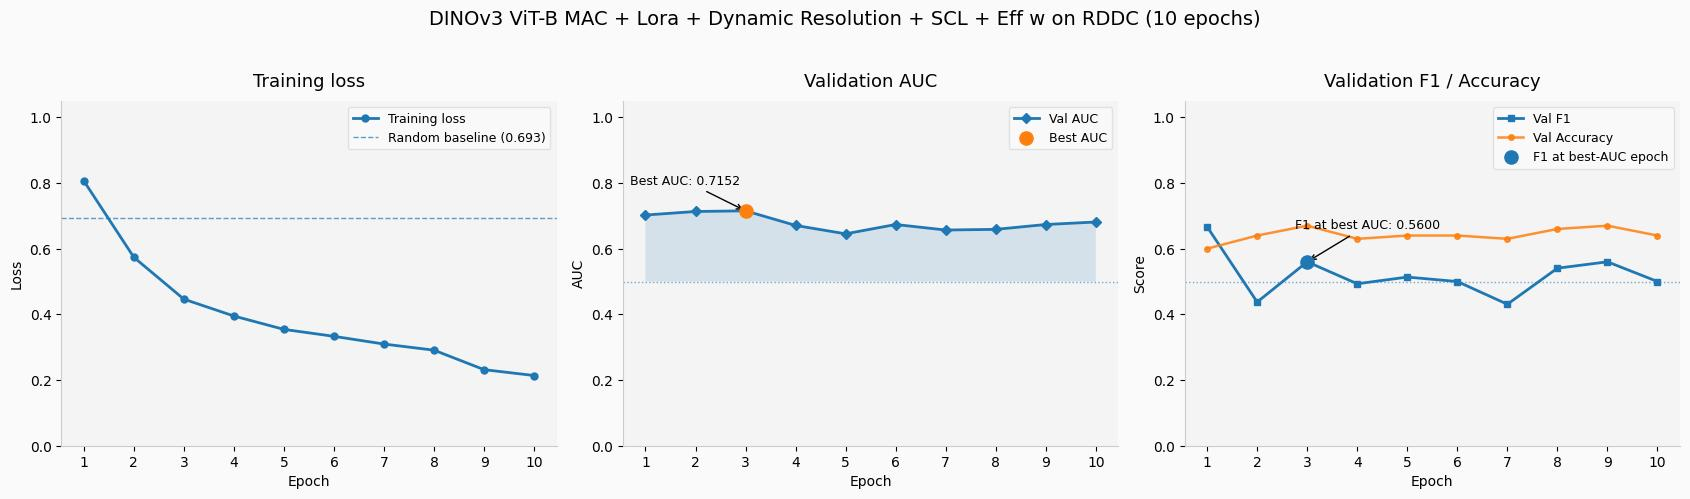

In [11]:
%matplotlib inline
import os, json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from IPython.display import Image, display

LOG_PATH = "/content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/log/mac_lora_dynres_scl_effort_weighted_train/log.txt"
def parse_dinov3_linear_json_log(path):
    all_entries = []

    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            try:
                entry = json.loads(line)
            except json.JSONDecodeError:
                continue

            if "epoch" in entry:
                all_entries.append(entry)

    if not all_entries:
        raise RuntimeError(f"No JSON epoch entries found in {path}")

    # Use only the last run if the log contains restarted runs
    runs = []
    current_run = []
    prev_epoch = -1

    for entry in all_entries:
        ep = int(entry.get("epoch", 0))

        if ep <= prev_epoch and current_run:
            runs.append(current_run)
            current_run = []

        current_run.append(entry)
        prev_epoch = ep

    if current_run:
        runs.append(current_run)

    entries = runs[-1]

    # Display epochs as 1-based
    epochs = [int(e["epoch"]) + 1 for e in entries]

    train_losses = [
        float(e.get("train_loss", np.nan))
        for e in entries
    ]

    val_aucs = [
        float(e.get("val_auc", np.nan))
        for e in entries
    ]

    val_f1s = [
        float(e.get("val_f1", np.nan))
        for e in entries
    ]

    val_accs = [
        float(e.get("val_acc", np.nan))
        for e in entries
    ]

    val_aps = [
        float(e.get("val_ap", np.nan))
        for e in entries
    ]

    return epochs, train_losses, val_aucs, val_f1s, val_accs, val_aps, len(runs)


def plot_training(path):
    epochs, losses, aucs, f1s, accs, aps, n_runs = parse_dinov3_linear_json_log(path)

    aucs_np = np.array(aucs, dtype=float)
    best_auc_idx = int(np.nanargmax(aucs_np))

    best_auc_epoch = epochs[best_auc_idx]
    best_auc = aucs[best_auc_idx]
    f1_at_best_auc = f1s[best_auc_idx]
    acc_at_best_auc = accs[best_auc_idx]

    print(f"Best AUC: {best_auc:.4f} at epoch {best_auc_epoch}")
    print(f"F1 at best AUC epoch: {f1_at_best_auc:.4f} at epoch {best_auc_epoch}")
    print(f"Accuracy at best AUC epoch: {acc_at_best_auc:.4f} at epoch {best_auc_epoch}")
    print(f"Detected runs in log: {n_runs}")

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
    fig.patch.set_facecolor("#FAFAFA")

    for ax in axes:
        ax.set_facecolor("#F4F4F4")
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#CCCCCC")
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    # 1. Training loss
    ax = axes[0]
    ax.plot(
        epochs,
        losses,
        marker="o",
        linewidth=2,
        markersize=5,
        label="Training loss",
    )
    ax.axhline(
        0.693,
        linestyle="--",
        linewidth=1,
        alpha=0.7,
        label="Random baseline (0.693)",
    )
    ax.set_ylim(0, 1.05)
    ax.set_title("Training loss", fontsize=13, pad=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=9, framealpha=0.5)

    # 2. Validation AUC
    ax = axes[1]
    ax.plot(
        epochs,
        aucs,
        marker="D",
        linewidth=2,
        markersize=5,
        label="Val AUC",
    )
    ax.fill_between(epochs, 0.5, aucs, alpha=0.15)

    ax.scatter(best_auc_epoch, best_auc, s=90, zorder=5, label="Best AUC")
    ax.annotate(
        f"Best AUC: {best_auc:.4f}",
        xy=(best_auc_epoch, best_auc),
        xytext=(best_auc_epoch - max(epochs) * 0.12, best_auc + 0.08),
        fontsize=9,
        ha="center",
        arrowprops=dict(arrowstyle="->", lw=1),
    )
    ax.axhline(0.5, linestyle=":", linewidth=1, alpha=0.6)
    ax.set_ylim(0, 1.05)
    ax.set_title("Validation AUC", fontsize=13, pad=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("AUC")
    ax.legend(fontsize=9, framealpha=0.5)

    # 3. Validation F1 and Accuracy
    ax = axes[2]
    ax.plot(
        epochs,
        f1s,
        marker="s",
        linewidth=2,
        markersize=5,
        label="Val F1",
    )
    ax.plot(
        epochs,
        accs,
        marker="o",
        linewidth=1.8,
        markersize=4,
        alpha=0.85,
        label="Val Accuracy",
    )

    ax.scatter(
        best_auc_epoch,
        f1_at_best_auc,
        s=90,
        zorder=5,
        label="F1 at best-AUC epoch",
    )
    ax.annotate(
        f"F1 at best AUC: {f1_at_best_auc:.4f}",
        xy=(best_auc_epoch, f1_at_best_auc),
        xytext=(best_auc_epoch + max(epochs) * 0.12, f1_at_best_auc + 0.10),
        fontsize=9,
        ha="center",
        arrowprops=dict(arrowstyle="->", lw=1),
    )
    ax.axhline(0.5, linestyle=":", linewidth=1, alpha=0.6)
    ax.set_ylim(0, 1.05)
    ax.set_title("Validation F1 / Accuracy", fontsize=13, pad=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.legend(fontsize=9, framealpha=0.5)

    plt.suptitle(
        f"DINOv3 ViT-B MAC + Lora + Dynamic Resolution + SCL + Eff w on RDDC ({len(epochs)} epochs)",
        fontsize=14,
        y=1.03,
    )
    plt.tight_layout()

    out_path = "dinov3_mac_training_curves.jpg"
    plt.savefig(out_path, dpi=100, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close(fig)

    display(Image(out_path))


plot_training(LOG_PATH)

In [12]:
import shutil
from pathlib import Path

CKPT_DIR = Path("/content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/log/mac_lora_dynres_scl_effort_weighted_test")

if CKPT_DIR.exists():
    shutil.rmtree(CKPT_DIR)
    print("🧹 Old checkpoints deleted")

CKPT_DIR.mkdir(parents=True, exist_ok=True)
print("✅ Fresh checkpoint directory created:", CKPT_DIR)

✅ Fresh checkpoint directory created: /content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/log/mac_lora_dynres_scl_effort_weighted_test


In [13]:
BEST_PATH = "/content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/log/mac_lora_dynres_scl_effort_weighted_train/best.pth"
TEST_OUTPUT_DIR = "/content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/log/mac_lora_dynres_scl_effort_weighted_test"
os.makedirs(TEST_OUTPUT_DIR, exist_ok=True)

checkpoint = torch.load(BEST_PATH, map_location=device, weights_only=False)

model = DINOv3LoRAMACClassifier(
    model_name="/content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/hf_dinov3_vitb16",
    lora_r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    dropout=0.2,
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

test_metrics, test_probs, test_labels = evaluate(model, test_loader, device)

print("Best epoch:", checkpoint["epoch"])
print("Best val metrics:", checkpoint["val_metrics"])
print("TEST:", test_metrics)

with open(os.path.join(TEST_OUTPUT_DIR, "log.txt"), "w") as f:
    f.write(json.dumps({
        "best_epoch": int(checkpoint["epoch"]),
        "test_auc": float(test_metrics["auc"]),
        "test_ap": float(test_metrics["ap"]),
        "test_f1": float(test_metrics["f1"]),
        "test_acc": float(test_metrics["acc"]),
        "scl_weight": float(checkpoint.get("scl_weight", 0.01)),
        "effort_alpha": float(checkpoint.get("effort_alpha", 0.5)),
    }) + "\n")

np.save(os.path.join(TEST_OUTPUT_DIR, "test_probs.npy"), test_probs)
np.save(os.path.join(TEST_OUTPUT_DIR, "test_labels.npy"), test_labels)

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/125 [00:00<?, ?it/s]

Best epoch: 2
Best val metrics: {'auc': np.float64(0.7152), 'ap': np.float64(0.7701231696300386), 'f1': 0.56, 'acc': 0.67}
TEST: {'auc': np.float64(0.734548), 'ap': np.float64(0.7769372722351824), 'f1': 0.5821831869510665, 'acc': 0.667}


Test F1  : 0.5822
Test AUC : 0.7345
Precision: 0.7811
Recall   : 0.4640
Accuracy : 0.6670
Result   : 667/1000
════════════════════════════════════════════
  Confusion Matrix Results (Dino MAC Lora dynres scl eff reweight)
════════════════════════════════════════════
  TP (fake correctly detected) : 232
  TN (real correctly detected) : 435
  FP (real wrongly called fake): 65
  FN (fake wrongly called real): 268
--------------------------------------------


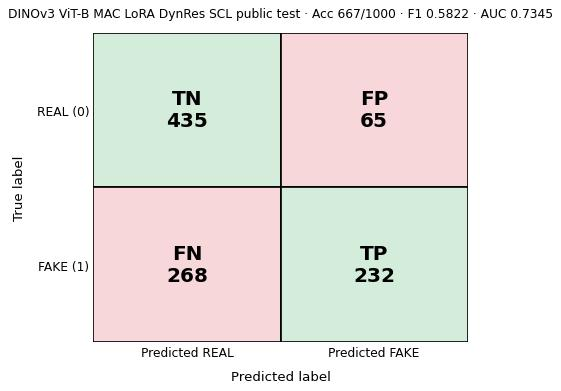

In [14]:
import os, json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image as IPyImage, display
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    average_precision_score,
)

MODEL_NAME = "DINOv3 ViT-B MAC LoRA DynRes SCL"
TEST_DIR = Path("/content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/log/mac_lora_dynres_scl_effort_weighted_test")
TEST_DIR.mkdir(parents=True, exist_ok=True)

PROBS_PATH = TEST_DIR / "test_probs.npy"
LABELS_PATH = TEST_DIR / "test_labels.npy"

test_probs = np.load(PROBS_PATH).reshape(-1)
test_labels = np.load(LABELS_PATH).astype(int).reshape(-1)

threshold = 0.5
test_preds = (test_probs >= threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(test_labels, test_preds, labels=[0, 1]).ravel()

precision = precision_score(test_labels, test_preds, zero_division=0)
recall = recall_score(test_labels, test_preds, zero_division=0)
f1 = f1_score(test_labels, test_preds, zero_division=0)
accuracy = accuracy_score(test_labels, test_preds)
auc = roc_auc_score(test_labels, test_probs)
ap = average_precision_score(test_labels, test_probs)

metric_summary = {
    "model": MODEL_NAME,
    "artifact_type": "metric_summary_from_inference",
    "threshold": threshold,
    "confusion_matrix": {
        "TP": int(tp),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
    },
    "metrics": {
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "accuracy": float(accuracy),
        "auc": float(auc),
        "ap": float(ap),
    },
}

with open(TEST_DIR / "metric_summary.json", "w") as f:
    json.dump(metric_summary, f, indent=2)

with open(TEST_DIR / "mac_test_summary.json", "w") as f:
    json.dump(metric_summary, f, indent=2)

np.save(TEST_DIR / "test_preds.npy", test_preds)

total = tp + tn + fp + fn
correct = tp + tn
wrong = fp + fn

print(f"Test F1  : {f1:.4f}")
print(f"Test AUC : {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"Accuracy : {accuracy:.4f}")
print(f"Result   : {correct}/{total}")

print(f"{'═'*44}")
print(f"  Confusion Matrix Results (Dino MAC Lora dynres scl eff reweight)")
print(f"{'═'*44}")
print(f"  TP (fake correctly detected) : {tp}")
print(f"  TN (real correctly detected) : {tn}")
print(f"  FP (real wrongly called fake): {fp}")
print(f"  FN (fake wrongly called real): {fn}")
print(f"{'-'*44}")

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor("white")

cell_labels = [["TN", "FP"], ["FN", "TP"]]
cell_values = [[tn, fp], [fn, tp]]
cell_colors = [
    ["#d4edda", "#f8d7da"],
    ["#f8d7da", "#d4edda"],
]

for i in range(2):
    for j in range(2):
        ax.add_patch(
            plt.Rectangle(
                (j, 1 - i), 1, 1,
                facecolor=cell_colors[i][j],
                edgecolor="black",
                linewidth=1.5,
            )
        )
        ax.text(
            j + 0.5,
            1 - i + 0.5,
            f"{cell_labels[i][j]}\n{cell_values[i][j]}",
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color="black",
        )

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_yticks([1.5, 0.5])
ax.set_xticklabels(["Predicted REAL", "Predicted FAKE"], fontsize=11)
ax.set_yticklabels(["REAL (0)", "FAKE (1)"], fontsize=11)
ax.set_xlabel("Predicted label", fontsize=12, labelpad=10)
ax.set_ylabel("True label", fontsize=12, labelpad=10)
ax.tick_params(length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    f"{MODEL_NAME} public test · Acc {correct}/{total} · F1 {f1:.4f} · AUC {auc:.4f}",
    fontsize=11,
    pad=14,
)

plt.tight_layout()

fig_path = TEST_DIR / "mac_lora_dynres_scl_effort_weighted_test_confusion_matrix.jpg"
plt.savefig(fig_path, dpi=80, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close(fig)

display(IPyImage(filename=str(fig_path)))

PublicTest: 667/1000 correct (66.7% accuracy)
REAL images: 500  |  FAKE images: 500
Well detected: 667  |  Badly detected: 333
TP=232, TN=435, FP=65, FN=268

REAL accuracy: 87.00%
FAKE accuracy: 46.40%
FAKE precision: 0.7811
FAKE recall: 0.4640
FAKE F1: 0.5822

Saved per-image results to: /content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/log/mac_lora_dynres_scl_effort_weighted_test/mac_lora_dynres_scl_effort_weighted_test_inference_results.json


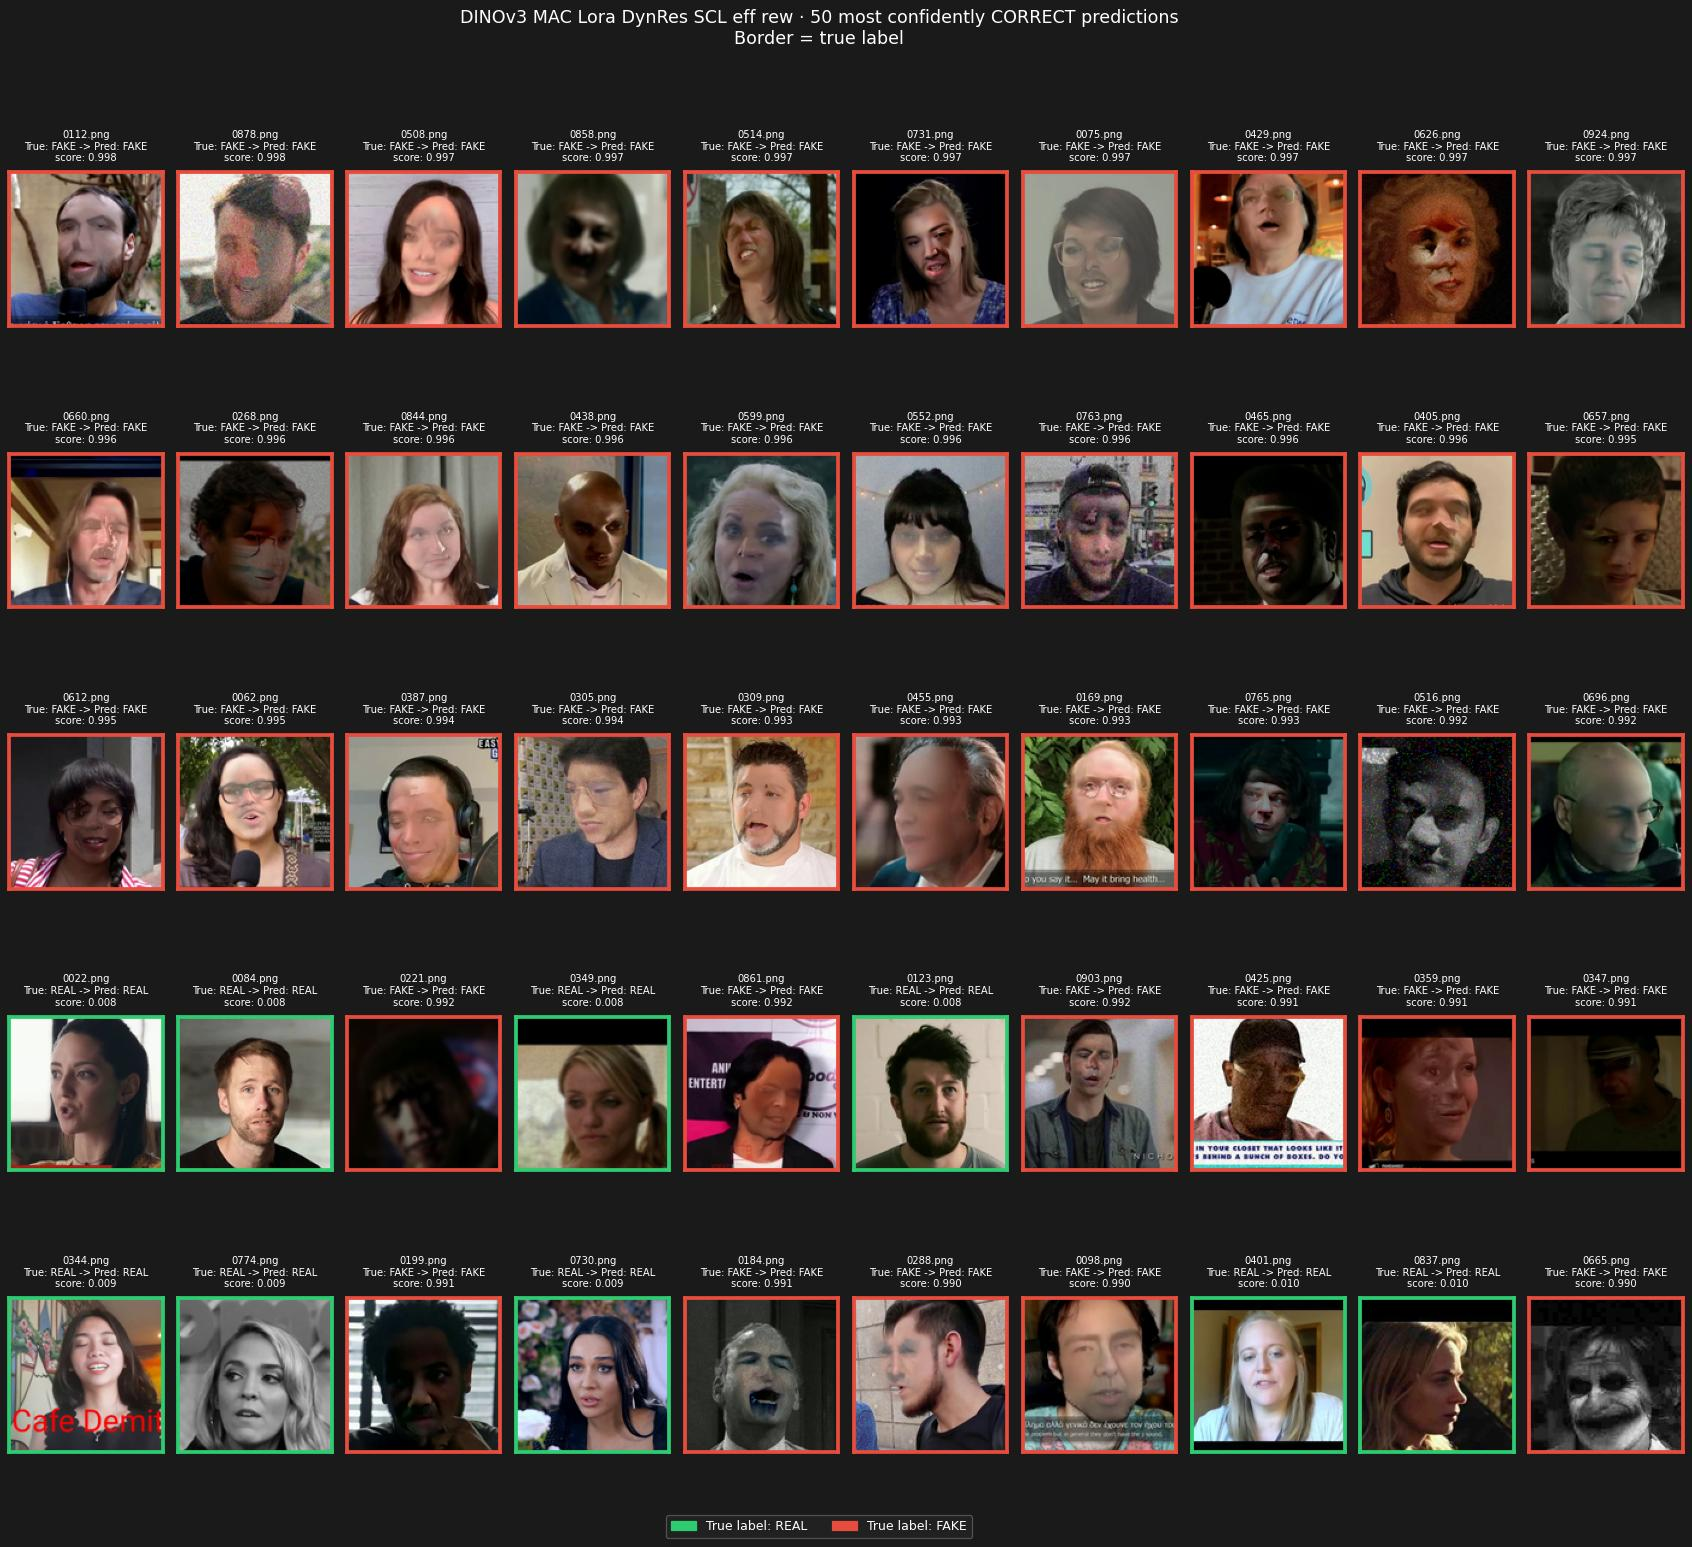

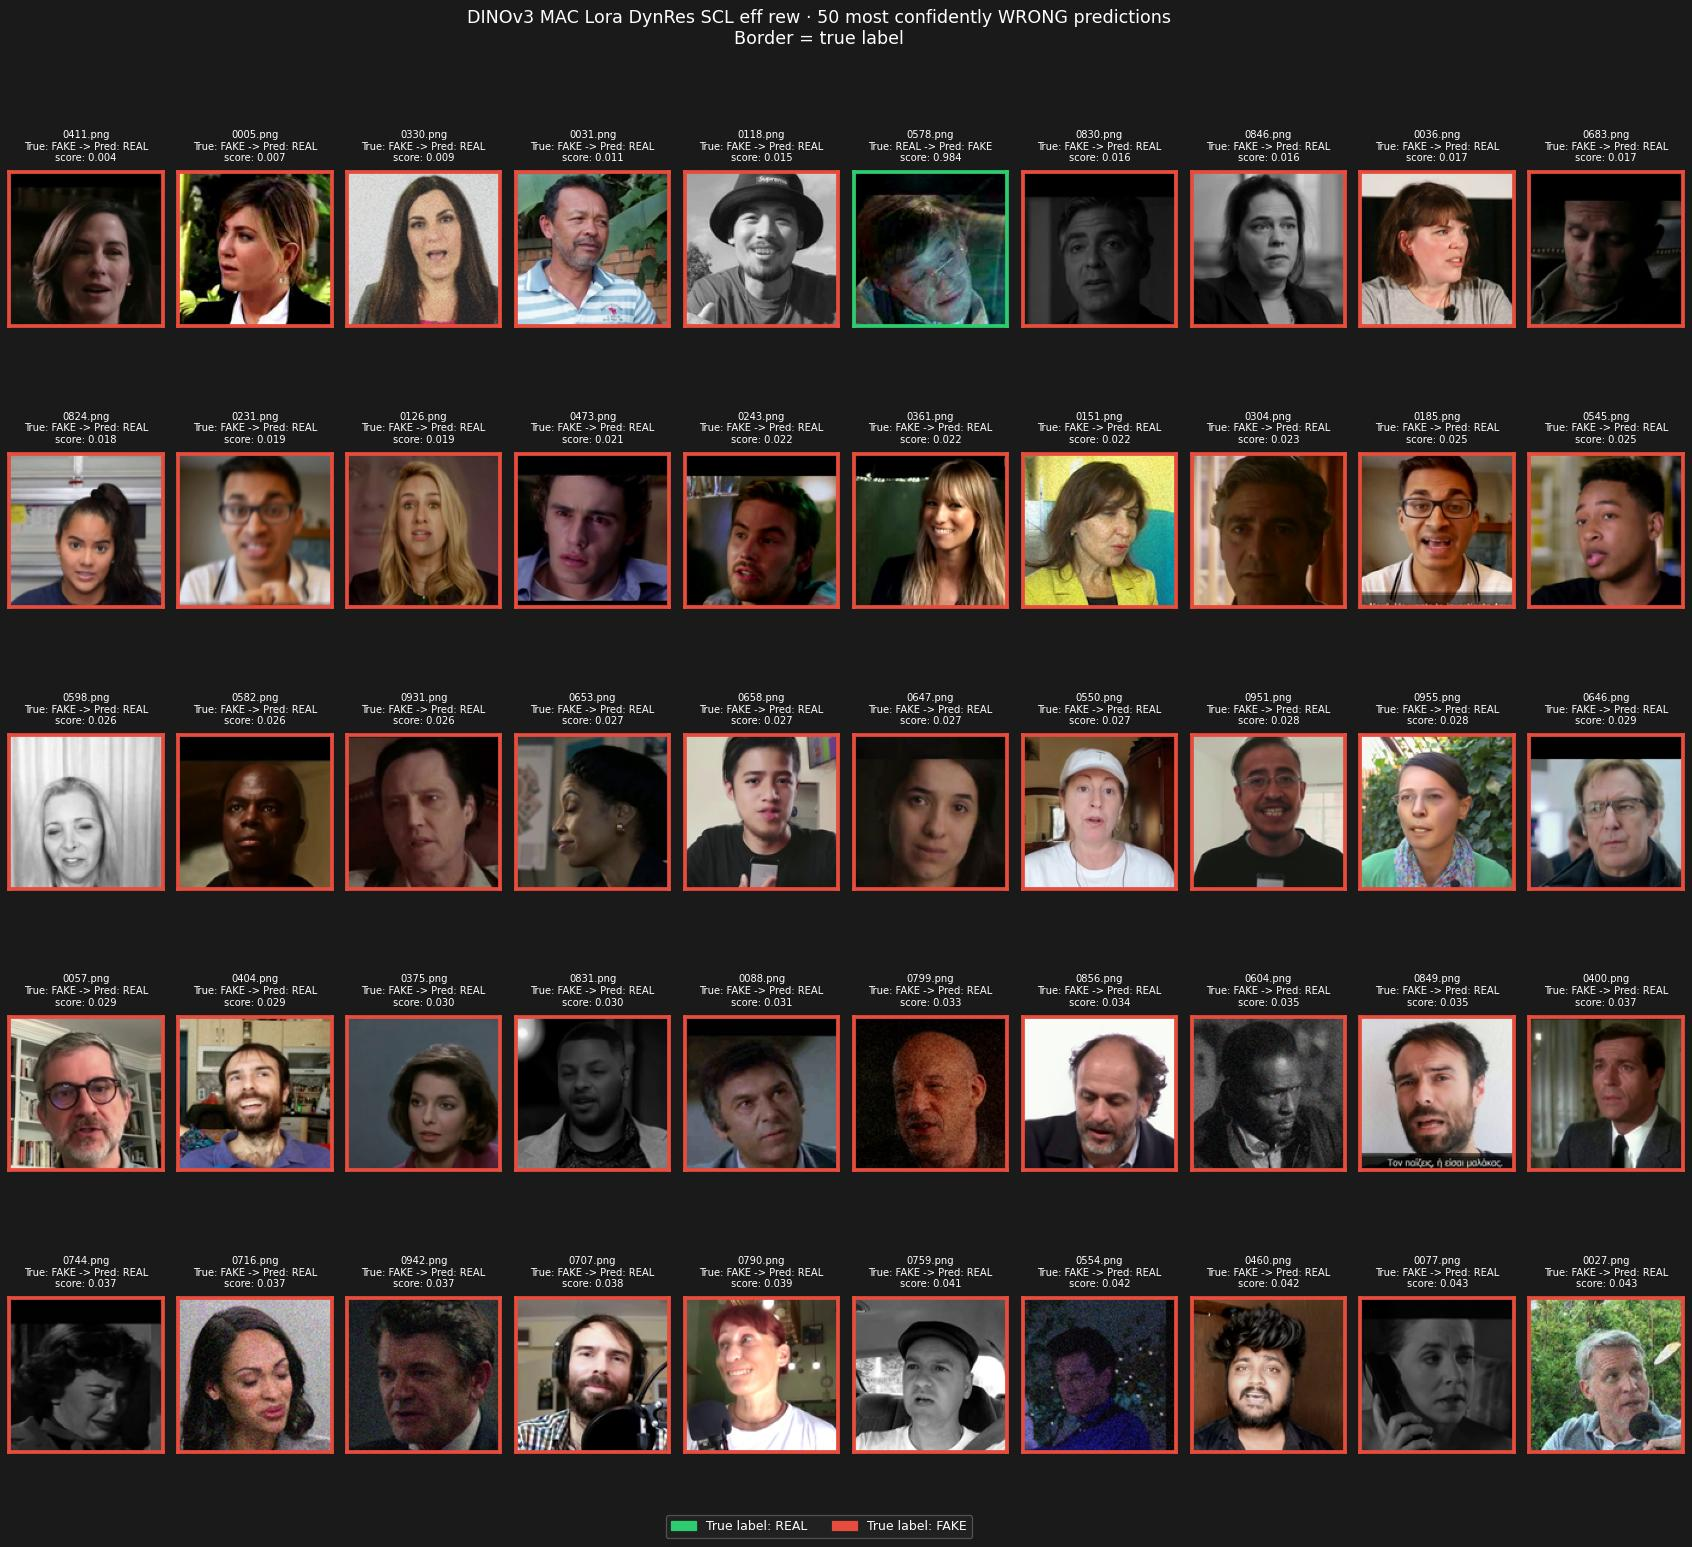


Saved figures:
 - /content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/log/mac_lora_dynres_scl_effort_weighted_test/dinov3_mac_lora_dynres_scl_effort_weighted_test_well_detected_test.jpg
 - /content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/log/mac_lora_dynres_scl_effort_weighted_test/dinov3_mac_lora_dynres_scl_effort_weighted_test_badly_detected_test.jpg


In [15]:
# ── Badly / Well Detected — DINOv3 MAC PublicTest ──

%matplotlib inline

import os
import json
import numpy as np
from pathlib import Path
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import Image as IPyImage, display

# ── Paths ─────────────────────────────────────────────────────────────────────
TEST_DIR = Path("/content/drive/MyDrive/Capstone_Hripsime_Working/Frameworks/DinoV3/log/mac_lora_dynres_scl_effort_weighted_test")
TEST_JSON = "/content/DiffusionForensics_Recons/test.json"

PROBS_PATH = TEST_DIR / "test_probs.npy"
LABELS_PATH = TEST_DIR / "test_labels.npy"

# ── Load test outputs ─────────────────────────────────────────────────────────
test_probs = np.load(PROBS_PATH).reshape(-1)
test_labels = np.load(LABELS_PATH).astype(int).reshape(-1)

with open(TEST_JSON, "r") as f:
    test_items = json.load(f)

assert len(test_items) == len(test_probs) == len(test_labels), \
    f"Mismatch: items={len(test_items)}, probs={len(test_probs)}, labels={len(test_labels)}"

# ── Build result records ──────────────────────────────────────────────────────
threshold = 0.5
results = []

for item, score, true_label in zip(test_items, test_probs, test_labels):
    pred = int(score >= threshold)
    results.append({
        "path": item["path"],
        "true_label": int(true_label),
        "pred": pred,
        "score": float(score),
        "confidence": float(score),
        "correct": pred == int(true_label),
    })

total = len(results)
n_correct = sum(r["correct"] for r in results)
accuracy = 100 * n_correct / total

well  = [r for r in results if r["correct"]]
badly = [r for r in results if not r["correct"]]

well_sorted  = sorted(well,  key=lambda x: abs(x["confidence"] - 0.5), reverse=True)
badly_sorted = sorted(badly, key=lambda x: abs(x["confidence"] - 0.5), reverse=True)

well_sample  = well_sorted[:50]
badly_sample = badly_sorted[:50]

n_real = sum(r["true_label"] == 0 for r in results)
n_fake = sum(r["true_label"] == 1 for r in results)

tp = sum((r["true_label"] == 1 and r["pred"] == 1) for r in results)
tn = sum((r["true_label"] == 0 and r["pred"] == 0) for r in results)
fp = sum((r["true_label"] == 0 and r["pred"] == 1) for r in results)
fn = sum((r["true_label"] == 1 and r["pred"] == 0) for r in results)

real_acc = 100 * tn / max(1, n_real)
fake_acc = 100 * tp / max(1, n_fake)
precision_fake = tp / max(1, tp + fp)
recall_fake = tp / max(1, tp + fn)
f1_fake = 2 * precision_fake * recall_fake / max(1e-12, precision_fake + recall_fake)

print(f"PublicTest: {n_correct}/{total} correct ({accuracy:.1f}% accuracy)")
print(f"REAL images: {n_real}  |  FAKE images: {n_fake}")
print(f"Well detected: {len(well)}  |  Badly detected: {len(badly)}")
print(f"TP={tp}, TN={tn}, FP={fp}, FN={fn}")
print(f"\nREAL accuracy: {real_acc:.2f}%")
print(f"FAKE accuracy: {fake_acc:.2f}%")
print(f"FAKE precision: {precision_fake:.4f}")
print(f"FAKE recall: {recall_fake:.4f}")
print(f"FAKE F1: {f1_fake:.4f}")

# ── Save per-image inference JSON inside mac_test ─────────────────────────────
RESULTS_JSON = TEST_DIR / "mac_lora_dynres_scl_effort_weighted_test_inference_results.json"

with open(RESULTS_JSON, "w") as f:
    json.dump(results, f, indent=2)

print("\nSaved per-image results to:", RESULTS_JSON)

# ── Helpers ───────────────────────────────────────────────────────────────────
def label_str(l):
    return "REAL" if l == 0 else "FAKE"

def load_thumb(path, size=128):
    img = PILImage.open(path).convert("RGB")
    w, h = img.size
    side = min(w, h)
    img = img.crop(((w - side) // 2, (h - side) // 2,
                    (w + side) // 2, (h + side) // 2))
    return img.resize((size, size), PILImage.LANCZOS)

def make_grid(samples, title, filename):
    n = len(samples)
    cols = 10
    rows = max(1, (n + cols - 1) // cols)

    fig, axes = plt.subplots(rows, cols, figsize=(24, rows * 3.5))
    fig.patch.set_facecolor('#1a1a1a')

    if rows == 1:
        axes = [axes]

    for idx, ax in enumerate([a for row in axes for a in row]):
        if idx >= n:
            ax.axis('off')
            continue

        r = samples[idx]
        try:
            ax.imshow(load_thumb(r["path"]))
        except Exception:
            ax.set_facecolor('#333')
            ax.text(0.5, 0.5, 'error', ha='center', va='center',
                    color='white', fontsize=7, transform=ax.transAxes)

        true_color = '#2ecc71' if r["true_label"] == 0 else '#e74c3c'
        for spine in ax.spines.values():
            spine.set_edgecolor(true_color)
            spine.set_linewidth(3)

        ax.set_xticks([])
        ax.set_yticks([])

        fname = os.path.basename(r["path"])
        ax.set_title(
            f"{fname}\nTrue: {label_str(r['true_label'])} -> Pred: {label_str(r['pred'])}\n"
            f"score: {r['confidence']:.3f}",
            fontsize=8,
            color='white',
            pad=9,
        )

    real_p = mpatches.Patch(color='#2ecc71', label='True label: REAL')
    fake_p = mpatches.Patch(color='#e74c3c', label='True label: FAKE')
    fig.legend(
        handles=[real_p, fake_p],
        loc='lower center',
        ncol=2,
        fontsize=10,
        framealpha=0.3,
        facecolor='#333',
        labelcolor='white',
        bbox_to_anchor=(0.5, 0.005),
    )

    fig.suptitle(title, fontsize=14, color='white', fontweight='medium')
    plt.subplots_adjust(hspace=0.7, wspace=0.1, top=0.88, bottom=0.06)

    plt.savefig(filename, dpi=90, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close(fig)
    display(IPyImage(filename=str(filename)))

# ── Plots ─────────────────────────────────────────────────────────────────────
well_fig = TEST_DIR / "dinov3_mac_lora_dynres_scl_effort_weighted_test_well_detected_test.jpg"
badly_fig = TEST_DIR / "dinov3_mac_lora_dynres_scl_effort_weighted_test_badly_detected_test.jpg"

make_grid(
    well_sample,
    title='DINOv3 MAC Lora DynRes SCL eff rew · 50 most confidently CORRECT predictions\nBorder = true label',
    filename=well_fig,
)

make_grid(
    badly_sample,
    title='DINOv3 MAC Lora DynRes SCL eff rew · 50 most confidently WRONG predictions\nBorder = true label',
    filename=badly_fig,
)

print("\nSaved figures:")
print(" -", well_fig)
print(" -", badly_fig)

In [16]:
import nbformat
NOTEBOOK_PATH = "/content/drive/MyDrive/Capstone_Hripsime_Working/Code Notebooks/dinov3 mac lora dynres scl effort weighted.ipynb"

nb = nbformat.read(NOTEBOOK_PATH, as_version=4)

if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

nbformat.write(nb, NOTEBOOK_PATH)

In [18]:
# Step 1 — install nbconvert (already available in Colab but just in case)
!pip install nbconvert -q
NOTEBOOK_PATH = "/content/drive/MyDrive/Capstone_Hripsime_Working/Code Notebooks/dinov3 mac lora dynres scl effort weighted.ipynb"
OUTPUT_DIR    = "/content/drive/MyDrive/Capstone_Hripsime_Working/Code Notebooks/HTML Notebooks"

!jupyter nbconvert \
    --to html \
    --embed-images \
    --output-dir "{OUTPUT_DIR}" \
    "{NOTEBOOK_PATH}"

print("Done — check your Drive for the .html file")

[NbConvertApp] Converting notebook /content/drive/MyDrive/Capstone_Hripsime_Working/Code Notebooks/dinov3 mac lora dynres scl effort weighted.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 1544639 bytes to /content/drive/MyDrive/Capstone_Hripsime_Working/Code Notebooks/HTML Notebooks/dinov3 mac lora dynres scl effort weighted.html
Done — check your Drive for the .html file
